# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

<p style="color: red; font-size: 32px;">LINK TO GITHUB: </p>

https://github.com/SylarJolly/CSCI-4047-800

In [ ]:
#imports and creating data frame.
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('./album_sales.csv')

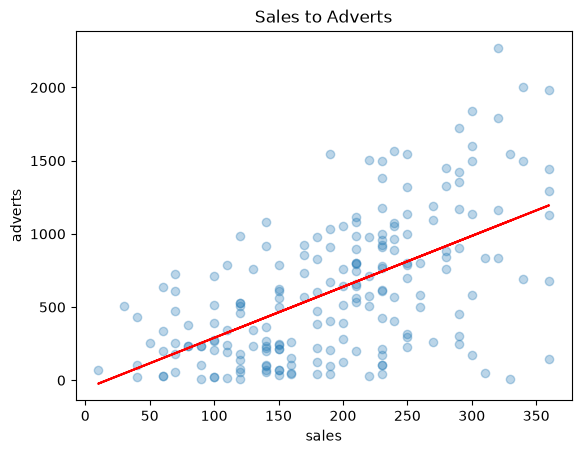

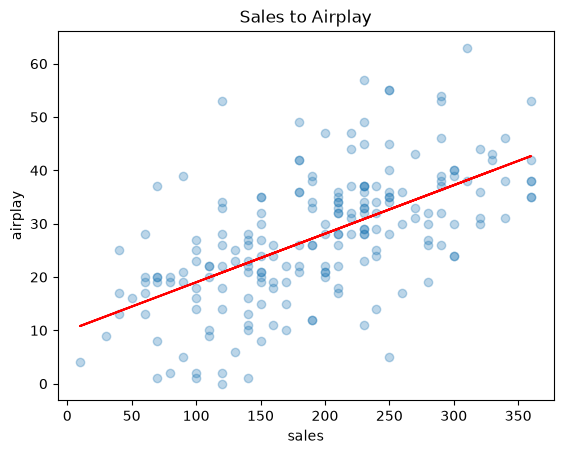

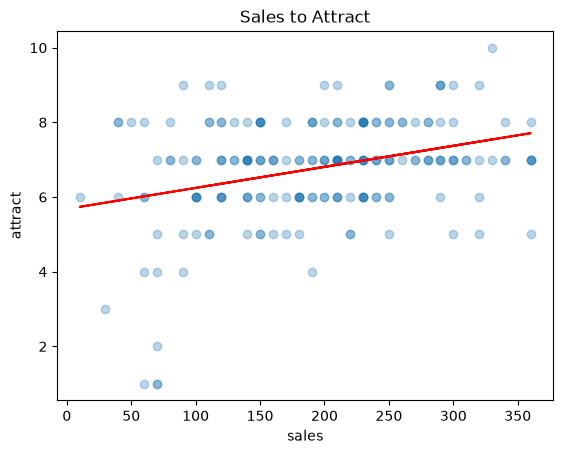

In [2]:
#--------SALES & ADVERTS SCATTER PLOT--------
x = df['sales']
y = df['adverts']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
predictions = model.predict(x)
plt.scatter(df['sales'], df['adverts'], alpha=.3)
plt.title("Sales to Adverts")
plt.xlabel('sales')
plt.ylabel('adverts')
plt.plot(x['sales'], predictions, color='red')
plt.show()

#--------SALES & AIRPLAY SCATTER PLOT--------
x = df['sales']
y = df['airplay']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
predictions = model.predict(x)
plt.scatter(df['sales'], df['airplay'], alpha=0.3)
plt.title("Sales to Airplay")
plt.xlabel('sales')
plt.ylabel('airplay')
plt.plot(x['sales'], predictions, color='red')
plt.show()

#--------SALES & ATTRACT SCATTER PLOT--------
x = df['sales']
y = df['attract']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
predictions = model.predict(x)
plt.scatter(df['sales'], df['attract'], alpha=0.3)
plt.title("Sales to Attract")
plt.xlabel('sales')
plt.ylabel('attract')
plt.plot(x['sales'], predictions, color='red')
plt.show()


In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

- *sales* and *adverts*

There is a moderately strong positive relationship. As sales increase, advertising spending generally increases as well. However, there is still considerable variation in the data.
- *sales* and *airplay*

There is also a moderately strong positive relationship. While the points are somewhat spread out, higher sales tend to be associated with more airplay.
- *sales* and *attract*

There is a weak positive relationship. The trend line slopes upward slightly, but the points are widely scattered and clustered around similar attract values.

Overall: All three scatterplots suggest that higher advertising, airplay, and attractiveness are generally associated with higher sales, with advertising and airplay showing stronger relationships than attractiveness.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [4]:
x = df['adverts']
y = df['sales']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x)

print(model.summary())

f_value = round(model.fvalue, 2)
p_value = round(model.f_pvalue, 2)

print(f"F Value: {f_value}")
print(f"P Value: {p_value}")


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        15:43:25   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The F-statistic is 99.59 and the P-value is 0.0, which indicates that the linear regression model is statistically significant. The P-value being less than 0.05 shows that there is a significant linear relationship between adverts and sales. So, the model is good and useful for explaining the relationship between the two variables.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [9]:
x = df['adverts']
y = df['sales']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
predictions = model.predict(x)

intercept = model.params['const']
coefficent = model.params['adverts']

budget = 135

album_sales = round((intercept + (coefficent * budget)),0)

print(f"Album sales: {album_sales}")

Album sales: 147.0


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [6]:
x = df[['adverts', 'airplay', 'attract']]
y = df['sales']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
predictions = model.predict(x) # will be used later
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        15:43:25   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

Model 2 is the better model because it has a higher R-squared value of 0.665 compared to Model 1's R-squared of 0.335. This means Model 2 explains about 66.5% of the variation in sales, while Model 1 only explains about 33.5%. The P-values for all three predictors in Model 2 are less than 0.05, suggesting that they are statistically significant (model 1 also has low p value but the higher r^2 value makes model 2 better).

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name